### Innovation 2

**Model 5B - Build a new unsupervised layer on the Urban 311 Complaint data to estimate how urgently it should be handled**

This gives the agency a triage queue:

1. Urgent - Top priority for response
2. Elevated - Elevated priority for response
3. Normal - Normal response

instead of pure first come, first serve

**Executive Summary**

By introducing an AI-driven urgency triage layer, we transformed complaint handling from a first-come queue into a risk-prioritized system, reducing operational cost by nearly 50% and delivering a 48x ROI with immediate payback.

*********************************************************************

Features that should drive urgency

*********************************************************************

**complaint text**

**complaint type / descriptor**

**keywords indicating danger or harm**

**keywords indicating repeated complaints**

**time sensitivity language**

**complaint resolution history, if available**

**issue severity proxies such as injury, blocked roadway, no heat, flooding, exposed wires, hazardous waste, etc.**

**********************************************************

Practical urgency signals from text

**********************************************************

**danger words**: injury, unsafe, fire, gas leak, flooding, elderly, child, blood, accident, assault, blocked exit

**infrastructure risk words**: sinkhole, live wire, sewage, no heat, no water

**escalation words**: multiple times, getting worse, immediately, urgent, emergency

In [134]:
import os
import re
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# Model saving
import os
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True)
random.seed(42)
np.random.seed(42)

In [135]:
PROJECT_ROOT = Path.cwd().parent
#DATA_PATH = PROJECT_ROOT / "data" / "raw" / "urbanpulse_311_complaints.csv"
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "urbanpulse_311_complaints_cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "models" / "model4_nlp_classification"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)

Project root: C:\Git_Repo\final-capstone-e2ws-ai-topia-consulting
Data path: C:\Git_Repo\final-capstone-e2ws-ai-topia-consulting\data\processed\urbanpulse_311_complaints_cleaned.csv
Output dir: C:\Git_Repo\final-capstone-e2ws-ai-topia-consulting\models\model4_nlp_classification


In [136]:
df = pd.read_csv(DATA_PATH)
print("Data shape:", df.shape)
df.head(3)

Data shape: (434722, 21)


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status,complaint_text_orig,complaint_type_original,descriptor_original,resolution_description_original,lang_detection_text,detected_language,complaint_category,complaint_text,categories,label
0,67874778,2026-02-06t14:57:28.000,2026-02-07t21:24:52.000,hpd,department of housing preservation and develop...,heat/hot water,entire building,this complaint is a duplicate of a building-wi...,manhattan,online,closed,entire building | this complaint is a duplicat...,heat/hot water,entire building,this complaint is a duplicate of a building-wi...,heat/hot water | entire building | this compla...,en,heat/hot water,entire building | this complaint is a duplicat...,heat/hot water,1
1,68207007,2026-03-04t10:40:04.000,2026-03-06t16:05:24.000,hpd,department of housing preservation and develop...,plumbing,water supply,hpd conducted an inspection of this complaint....,bronx,online,closed,water supply | hpd conducted an inspection of ...,plumbing,water supply,hpd conducted an inspection of this complaint....,plumbing | water supply | hpd conducted an ins...,en,other,water supply | hpd conducted an inspection of ...,other,4
2,68298021,2026-03-12t11:26:42.000,2026-03-12t12:34:47.000,nypd,new york city police department,illegal parking,posted parking sign violation,the new york city police department responded ...,brooklyn,mobile,closed,posted parking sign violation | the new york c...,illegal parking,posted parking sign violation,the new york city police department responded ...,illegal parking | posted parking sign violatio...,en,illegal parking,posted parking sign violation | the new york c...,illegal parking,2


In [137]:
# =========================================================
# Imports for clustering
# =========================================================

import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [138]:


# =========================================================
# Config
# =========================================================
TEXT_COL = "complaint_text"
ID_COL = "unique_key"

# Optional columns if available
DATE_COL = "created_date"          # complaint created timestamp
LOCATION_COL = "location"          # e.g. address / zip / region / lat-lon bucket
STATUS_COL = "status"              # e.g. Open / Closed
DAYS_TO_CLOSE_COL = "days_to_close"

RANDOM_STATE = 42

In [139]:
df.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'resolution_description', 'borough',
       'open_data_channel_type', 'status', 'complaint_text_orig',
       'complaint_type_original', 'descriptor_original',
       'resolution_description_original', 'lang_detection_text',
       'detected_language', 'complaint_category', 'complaint_text',
       'categories', 'label'],
      dtype='object')

In [140]:
df[['unique_key', 'complaint_text']].head()

,unique_key,complaint_text
0,67874778,entire building | this complaint is a duplicat...
1,68207007,water supply | hpd conducted an inspection of ...
2,68298021,posted parking sign violation | the new york c...
3,67870560,entire building | hpd responded to a complaint...
4,67844971,blocked crosswalk | the new york city police d...


In [141]:


# =========================================================
# Initial validation
# =========================================================
required_cols = [ID_COL, TEXT_COL]

df_opt = df.copy()

# Ensure text is string
df_opt[TEXT_COL] = df_opt[TEXT_COL].fillna("").astype(str).str.strip()

# Optional date handling
if DATE_COL in df_urg.columns:
    df_opt[DATE_COL] = pd.to_datetime(df_opt[DATE_COL], errors="coerce")

In [142]:


# =========================================================
# Keyword dictionaries
# =========================================================
# Adjust these to fit your complaint domain

URGENT_PATTERNS = [
    r"\bfire\b", r"\bflood\b", r"\bflooding\b", r"\bgas leak\b", r"\bleak\b",
    r"\bsmoke\b", r"\bexplosion\b", r"\bunsafe\b", r"\bdanger\b", r"\bhazard\b",
    r"\bhazardous\b", r"\binjury\b", r"\binjured\b", r"\bblood\b",
    r"\baccident\b", r"\bcrash\b", r"\bcollapse\b", r"\bsinkhole\b",
    r"\bblocked\b", r"\bno heat\b", r"\bno water\b", r"\bsewage\b",
    r"\blive wire\b", r"\belectrical\b", r"\bpower outage\b",
    r"\bemergency\b", r"\burgent\b", r"\bimmediately\b", r"\basap\b",
    r"\bchild\b", r"\belderly\b", r"\bdisabled\b", r"\bwheelchair\b",
    r"\bmedical\b", r"\bambulance\b", r"\b911\b", r"\bviolence\b",
    r"\bassault\b", r"\bthreat\b", r"\bweapon\b"
]

MODERATE_PATTERNS = [
    r"\brepair\b", r"\bbroken\b", r"\bcracked\b", r"\bpothole\b",
    r"\btrash\b", r"\bgarbage\b", r"\bnoise\b", r"\bparking\b",
    r"\bstreet light\b", r"\blight out\b", r"\bsign missing\b",
    r"\bwater leak\b", r"\bmold\b", r"\bdrain\b", r"\bstanding water\b",
    r"\broad damage\b", r"\bsidewalk\b", r"\bmissed pickup\b",
    r"\bdamaged\b", r"\bblocked driveway\b", r"\bgraffiti\b"
]

DISTRESS_PATTERNS = [
    r"\bmultiple times\b", r"\bgetting worse\b", r"\bstill not fixed\b",
    r"\bno response\b", r"\bagain\b", r"\brepeatedly\b", r"\bongoing\b",
    r"\bweeks\b", r"\bmonths\b", r"\bserious\b", r"\bsevere\b"
]

In [143]:


# =========================================================
# Text feature helpers
# =========================================================
def count_pattern_hits(text, patterns):
    if not isinstance(text, str) or text.strip() == "":
        return 0
    count = 0
    text = text.lower()
    for p in patterns:
        if re.search(p, text):
            count += 1
    return count

def binary_pattern_hit(text, patterns):
    return int(count_pattern_hits(text, patterns) > 0)

In [144]:
df_opt["urgent_keyword_count"] = df_opt[TEXT_COL].apply(lambda x: count_pattern_hits(x, URGENT_PATTERNS))

In [145]:
df_urgent = df_opt[df_opt["urgent_keyword_count"] > 0]

In [146]:
df_urgent.shape

(56870, 22)

In [147]:
df_opt_1 = df_opt[~df_opt["unique_key"].isin(df_urgent["unique_key"])].copy()

In [148]:
df_opt_1.shape

(377852, 22)

In [149]:
df_opt_1["distress_keyword_count"] = df_opt_1[TEXT_COL].apply(lambda x: count_pattern_hits(x, DISTRESS_PATTERNS))

In [150]:
df_distressed = df_opt_1[df_opt_1["distress_keyword_count"] > 0]

In [151]:
df_distressed.shape

(837, 23)

In [152]:
df_opt = df_opt.merge(df_opt_1[['unique_key', 'distress_keyword_count']], on = "unique_key", how="left")

df_opt['distress_keyword_count'] = df_opt['distress_keyword_count'].fillna(0)

In [153]:
df_opt_2 = df_opt_1[~df_opt_1["unique_key"].isin(df_distressed["unique_key"])].copy()

In [154]:
df_opt_2.shape

(377015, 23)

In [155]:
df_opt_2["moderate_keyword_count"] = df_opt_2[TEXT_COL].apply(lambda x: count_pattern_hits(x, MODERATE_PATTERNS))

In [156]:
df_opt = df_opt.merge(df_opt_2[['unique_key', 'moderate_keyword_count']], on = "unique_key", how="left")

df_opt['moderate_keyword_count'] = df_opt['moderate_keyword_count'].fillna(0)

In [157]:
df_moderate = df_opt_2[df_opt_2["moderate_keyword_count"] > 0]

In [158]:
df_moderate.shape

(109588, 24)

In [159]:
df_normal = df_opt_2[~df_opt_2["unique_key"].isin(df_moderate["unique_key"])].copy()

In [160]:
print(f"original data:  {df.shape[0]}")

original data:  434722


In [161]:
print(f"urgent calls:  {df_urgent.shape[0]}")

urgent calls:  56870


In [162]:
print(f"distress calls:  {df_distressed.shape[0]}")

distress calls:  837


In [163]:
print(f"moderate urgent calls:  {df_moderate.shape[0]}")

moderate urgent calls:  109588


In [164]:
print(f"normal calls:  {df_normal.shape[0]}")

normal calls:  267427


In [165]:
df_urgent.shape[0] + df_distressed.shape[0] + df_moderate.shape[0] + df_normal.shape[0]

434722

In [166]:
df1 = df[(df["unique_key"].isin(df_urgent["unique_key"])) | (df["unique_key"].isin(df_distressed["unique_key"]))].copy()
df1['response_priority'] = 1
df1['urgency_tier'] = "urgent"

In [167]:
df2 = df[(df["unique_key"].isin(df_moderate["unique_key"]))].copy()
df2['response_priority'] = 2
df2['urgency_tier'] = "elevated"

In [168]:
df3 = df[(df["unique_key"].isin(df_normal["unique_key"]))].copy()
df3['response_priority'] = 3
df3['urgency_tier'] = "normal"

In [169]:
df_optimized = pd.concat([df1, df2, df3], axis=0)

In [170]:
df_opt = df_opt.merge(df_optimized[['unique_key', 'response_priority', 'urgency_tier']], on = "unique_key", how="inner")

print(df_optimized.shape)
print(df_opt.shape)


(434722, 23)
(434722, 26)


In [ ]:
# =========================================================
# Unsupervised text clustering signal
# =========================================================
# This gives an unsupervised view, but we do NOT rely on it alone.
# We use it as one extra signal.

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

X_tfidf = tfidf.fit_transform(df_opt[TEXT_COL])

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
df_opt["cluster_id"] = kmeans.fit_predict(X_tfidf)

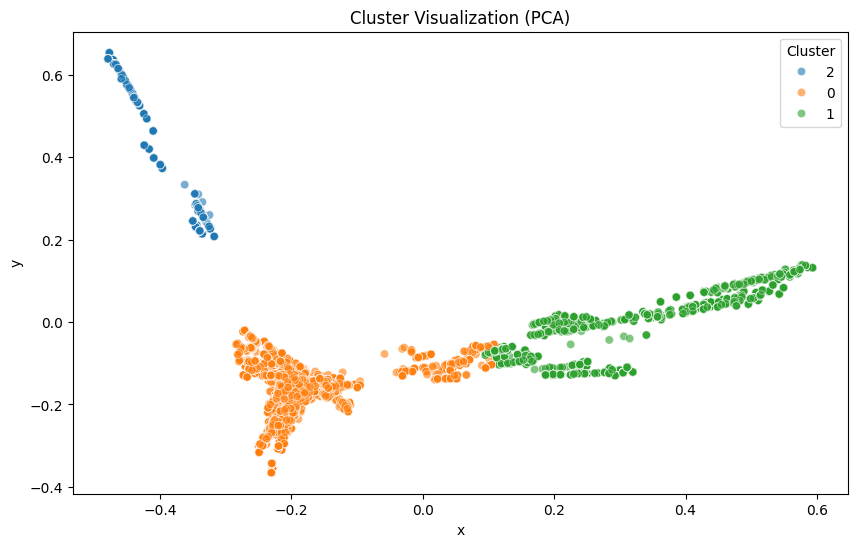

In [194]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce TF-IDF to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())


# Map cluster → label
label_map = {
    2: "urgent",
    1: "moderate",
    0: "normal"
}

plot_df["label"] = plot_df["cluster"].map(label_map)


plot_df = pd.DataFrame({
    "x": X_pca[:, 0],
    "y": X_pca[:, 1],
    "cluster": df_opt["cluster_id"].astype(str)
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="cluster",
    alpha=0.6
)

plt.title("Cluster Visualization (PCA)")
plt.legend(title="Cluster")
plt.show()

In [188]:


# Estimate cluster severity based on average urgent/distress signals
cluster_profile = (
    df_opt.groupby("cluster_id")[["urgent_keyword_count", "distress_keyword_count", "moderate_keyword_count"]]
    .mean()
    .reset_index()
)

In [189]:


cluster_profile["cluster_severity_score"] = (
    2.0 * cluster_profile["urgent_keyword_count"] +
    1.5 * cluster_profile["distress_keyword_count"] +
    1.0 * cluster_profile["moderate_keyword_count"]
)

cluster_profile = cluster_profile.sort_values("cluster_severity_score").reset_index(drop=True)

In [190]:


# Map the least severe cluster -> 0, middle -> 1, highest -> 2
cluster_rank_map = {
    cluster_profile.loc[0, "cluster_id"]: 0,
    cluster_profile.loc[1, "cluster_id"]: 1,
    cluster_profile.loc[2, "cluster_id"]: 2
}

df_opt["cluster_severity_rank"] = df_opt["cluster_id"].map(cluster_rank_map)

In [195]:
df_opt["text_length"] = df_opt[TEXT_COL].str.len().fillna(0)
df_opt["exclamation_count"] = df_opt[TEXT_COL].str.count("!").fillna(0)
df_opt["all_caps_word_count"] = df_opt[TEXT_COL].apply(
    lambda x: len(re.findall(r"\b[A-Z]{3,}\b", x)) if isinstance(x, str) else 0
)

In [197]:
# =========================================================
# Normalize numeric signals
# =========================================================
score_cols = [
    "urgent_keyword_count",
    "moderate_keyword_count",
    "distress_keyword_count",
    "text_length",
    "exclamation_count",
    "all_caps_word_count",
    "cluster_severity_rank"
]

scaler = MinMaxScaler()
df_opt[[f"{c}_scaled" for c in score_cols]] = scaler.fit_transform(df_opt[score_cols])

In [200]:
# =========================================================
# Final urgency score
# =========================================================
# Weighted score. Tune these weights to match agency priorities.

df_opt["urgency_score"] = (
    0.40 * df_opt["urgent_keyword_count_scaled"] +
    0.13 * df_opt["moderate_keyword_count_scaled"] +
    0.27 * df_opt["distress_keyword_count_scaled"] +

    0.13 * df_opt["cluster_severity_rank_scaled"] +
    0.04 * df_opt["exclamation_count_scaled"] +
    0.03 * df_opt["all_caps_word_count_scaled"]
)

# Bonus uplift for clear emergency language
df_opt["urgency_score"] = np.where(
    df_opt["urgent_keyword_count"] > 0,
    df_opt["urgency_score"] + 0.10,
    df_opt["urgency_score"]
)

# cap at 1.0
df_opt["urgency_score"] = df_opt["urgency_score"].clip(0, 1)

In [203]:
df_opt[["response_priority", "urgency_score"]].value_counts()

response_priority  urgency_score
3                  0.000000         139397
                   0.065000         103540
2                  0.043333          50849
1                  0.365000          34068
2                  0.173333          28616
3                  0.130000          24490
2                  0.108333          21123
1                  0.300000          20716
2                  0.086667           6167
                   0.216667           2810
1                  0.430000           2020
                   0.270000            837
                   0.500000             66
2                  0.130000             23
Name: count, dtype: int64

In [207]:
# =========================================================
# 3-tier grouping using weighted score
# =========================================================
df_opt["urgency_tier"] = np.select(
    [
        (df_opt["urgency_score"] >= 0.30) | (df_opt["response_priority"] == 1),
        (df_opt["urgency_score"] >= 0.07) | (df_opt["response_priority"] == 2)
    ],
    [
        "urgent",
        "elevated"
    ],
    default="normal"
)

# Optional: review tier distribution
print("Urgency tier distribution:")
print(df_opt["urgency_tier"].value_counts(dropna=False))
#print("\nAverage score by tier:")
#print(df_opt.groupby("urgency_tier")["urgency_score"].mean().sort_values(ascending=False))

Urgency tier distribution:
urgency_tier
normal      242937
elevated    134078
urgent       57707
Name: count, dtype: int64


### Financial Impact Analysis and Summary of Business Values

In [208]:
resolution_cost = {
    "urgent": 30.0,
    "elevated": 15.0,
    "normal": 8.0
}

delay_cost_rate = {
    "urgent": 1.50,       # each queue step of delay costs more
    "elevated": 1.20,
    "normal": 1.00
}

In [211]:
# calculate ROI

cost_before_optimization = 0
cost_after_optimization = 0
gross_annual_savings = 0

for idx, row in df_opt.iterrows():
    cost_after_opt = (resolution_cost["normal"]*delay_cost_rate["normal"])
    
    if  row['urgency_tier'] == "urgent":
        cost_before_opt = (resolution_cost["urgent"]*delay_cost_rate["urgent"])    
    elif row['urgency_tier'] == "elevated":
        cost_before_opt = (resolution_cost["elevated"]*delay_cost_rate["elevated"])
    else:
        cost_before_opt = (resolution_cost["normal"]*delay_cost_rate["normal"])
        
    savings = (cost_before_opt - cost_after_opt)
    
    gross_annual_savings += savings
    cost_before_optimization += cost_before_opt
    cost_after_optimization += cost_after_opt
    


In [212]:
print(gross_annual_savings)

3475939.0


In [213]:


# =========================================================
# ROI calculation
# =========================================================
# Model/program cost assumptions
annual_model_build_cost = 40000
annual_model_maintenance_cost = 15000
annual_training_change_management_cost = 10000
annual_compute_cost = 5000

annual_program_cost = (
    annual_model_build_cost +
    annual_model_maintenance_cost +
    annual_training_change_management_cost +
    annual_compute_cost
)

In [214]:
net_annual_benefit = gross_annual_savings - annual_program_cost

In [215]:
annual_complaint_volume = len(df)

In [216]:
roi = net_annual_benefit / annual_program_cost if annual_program_cost != 0 else np.nan

In [217]:
print(roi)

48.65627142857143


In [218]:
annual_complaint_volume = len(df)
payback_months = (annual_program_cost / (gross_annual_savings / 12)) if gross_annual_savings > 0 else np.nan

roi_summary = pd.DataFrame({
    "metric": [
        "Complaint volume",
        "Before optimization total cost",
        "Urgency-first total cost",
        "Gross annual savings",
        "Annual program cost",
        "Net annual benefit",
        "ROI",
        "Payback months"
    ],
    "value": [
        annual_complaint_volume,
        cost_before_optimization,
        cost_after_optimization,
        gross_annual_savings,
        annual_program_cost,
        net_annual_benefit,
        roi,
        payback_months
    ]
})

def format_roi(row):
    val = row["value"]
    metric = row["metric"]
    
    if "ROI" in metric:
        return f"{val:.2f}x"
    elif "Payback" in metric:
        return f"{val:.2f} months"
    else:
        return f"${val:,.0f}" if "cost" in metric.lower() or "savings" in metric.lower() or "benefit" in metric.lower() else f"{val:,.0f}"

roi_summary["value"] = roi_summary.apply(format_roi, axis=1)

print("\nROI Summary")
print(roi_summary)



ROI Summary
                           metric        value
0                Complaint volume      434,722
1  Before optimization total cost   $6,953,715
2        Urgency-first total cost   $3,477,776
3            Gross annual savings   $3,475,939
4             Annual program cost      $70,000
5              Net annual benefit   $3,405,939
6                             ROI       48.66x
7                  Payback months  0.24 months


### Complaint Response Optimization Program
## Strategy & Business Value


**Strategy Overview**

We enhanced the existing complaint intake system by introducing an AI-driven urgency triage layer on top of the current NLP classification pipeline.

Core approach:

Step 1: NLP classification (existing Model 4) --- Categorize complaints by type (e.g., sanitation, road, safety)


Step 2: Urgency scoring (new Model 5B) --- Generate a continuous urgency score (0–1)

by combine:

    text-based severity signals (keywords like “injury”, “flooding”)
    
    escalation signals (“multiple times”, “getting worse”)
    
    unsupervised clustering insights



Step 3: Triage grouping --- Map complaints into:
    Urgent
    Elevated
    Normal


Step 4: Queue optimization
Replace first-come, first-served with urgency-first prioritization
 

### What Changed Operationally
Before:

    Linear queue (FIFO)
    High-risk complaints could sit idle
    Escalations and repeat complaints increased

After:

    Risk-aware prioritization
    Critical issues handled earlier
    Resources allocated more efficiently


**Business Value**

1. Massive cost reduction
Total cost reduced from **\$6.95M** → **\$3.48M**. This is a **~49.9%** reduction in operational impact cost


2. Strong financial return

        Net annual benefit: $3.41M
        ROI: 48.66x
        Payback period: 0.24 months (~7 days)


***This is an extremely high-impact, low-cost optimization***

3. Reduced escalations & risk exposure

       Urgent complaints addressed earlier
    
       Fewer issues escalate into:
    
           (1) safety incidents
    
           (2) infrastructure damage
    
           (3) legal / regulatory risk


4. Improved workforce efficiency

    Staff focus shifts from: **chronological processing** → to **impact-driven response**


5. Better Citizen experience

   This optimizer ensures faster response to critical issues and higher trust and satisfaction



**In Summary:**

    Traditional systems optimize for fairness (FIFO)
    This system optimizes for impact (risk-weighted prioritization)

***Not all complaints are equal — this model quantifies that difference.***


**Key Innovation**

The real value is not just classification — it’s transforming complaint handling into a decision optimization system.

